In [1]:
from run_simulation import run_simulation, print_statistics
import simpy

# Run the simulation
print("Running simulation with 8000 permits...")
sim = run_simulation(
    num_permits=8000,
    random_seed=42,
    inter_arrival_time=1.0  # 1 day between arrivals
)

# Get and display statistics
stats = sim.get_statistics()
print_statistics(stats)

Running simulation with 8000 permits...

SIMULATION STATISTICS

Total Completed Permits: 4760
Total In Progress: 240

--------------------------------------------------------------------------------
SEGMENT DISTRIBUTION
--------------------------------------------------------------------------------
  CUSTOM_LIKE                   : 3408 (71.60%)
  CUSTOM_NON_LIKE               :  889 (18.68%)
  PRE_APPROVED_LIKE             :   85 ( 1.79%)
  PRE_APPROVED_NON_LIKE         :   15 ( 0.32%)
  SELF_CERT_LIKE                :  283 ( 5.95%)
  SELF_CERT_NON_LIKE            :   80 ( 1.68%)

--------------------------------------------------------------------------------
OVERALL PROCESSING TIME STATISTICS
--------------------------------------------------------------------------------
  Mean:     241.95 days
  Median:   217.77 days
  Std Dev:  117.29 days
  Min:       10.82 days
  Max:     1571.01 days

--------------------------------------------------------------------------------
PROCESSING 

In [2]:
# Optional: Access individual permit data
print(f"\nFirst 5 completed permits:")
for permit in sim.completed_permits[:5]:
    total_time = permit.ready_for_construction - permit.created_at if permit.ready_for_construction else None
    print(f"  Permit {permit.permit_id} ({permit.segment.name}): "
          f"{total_time:.2f} days total, "
          f"{permit.public_works_rechecks} re-checks")



First 5 completed permits:
  Permit 28 (PRE_APPROVED_LIKE): 51.16 days total, 0 re-checks
  Permit 39 (PRE_APPROVED_LIKE): 48.43 days total, 0 re-checks
  Permit 23 (CUSTOM_LIKE): 78.56 days total, 0 re-checks
  Permit 15 (CUSTOM_LIKE): 98.81 days total, 0 re-checks
  Permit 3 (CUSTOM_LIKE): 115.84 days total, 0 re-checks


Creating visualizations for 4760 permits...
  Creating stacked bar chart...
  Creating Gantt chart...
  Creating average time by stage chart...
  Creating time by segment chart...
  Creating total time by segment chart...


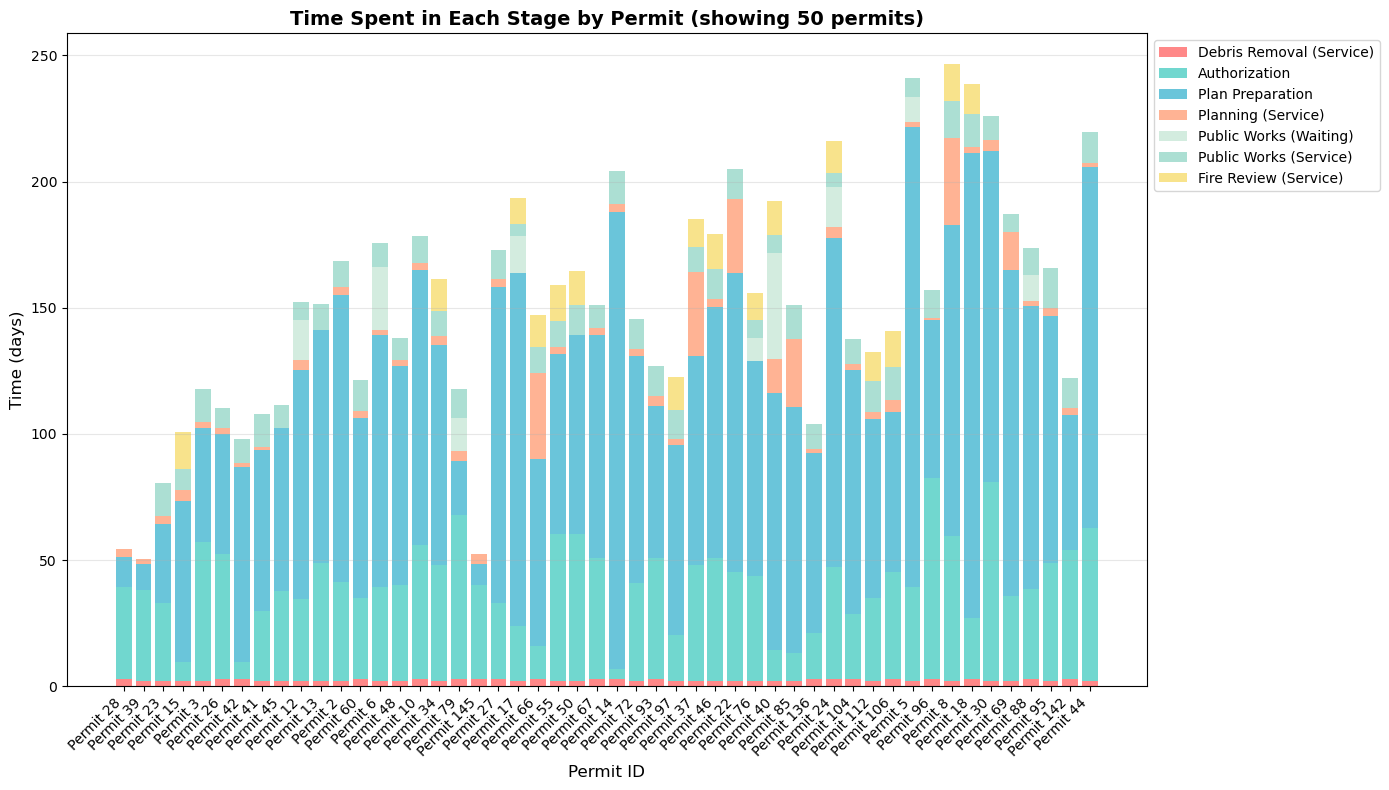

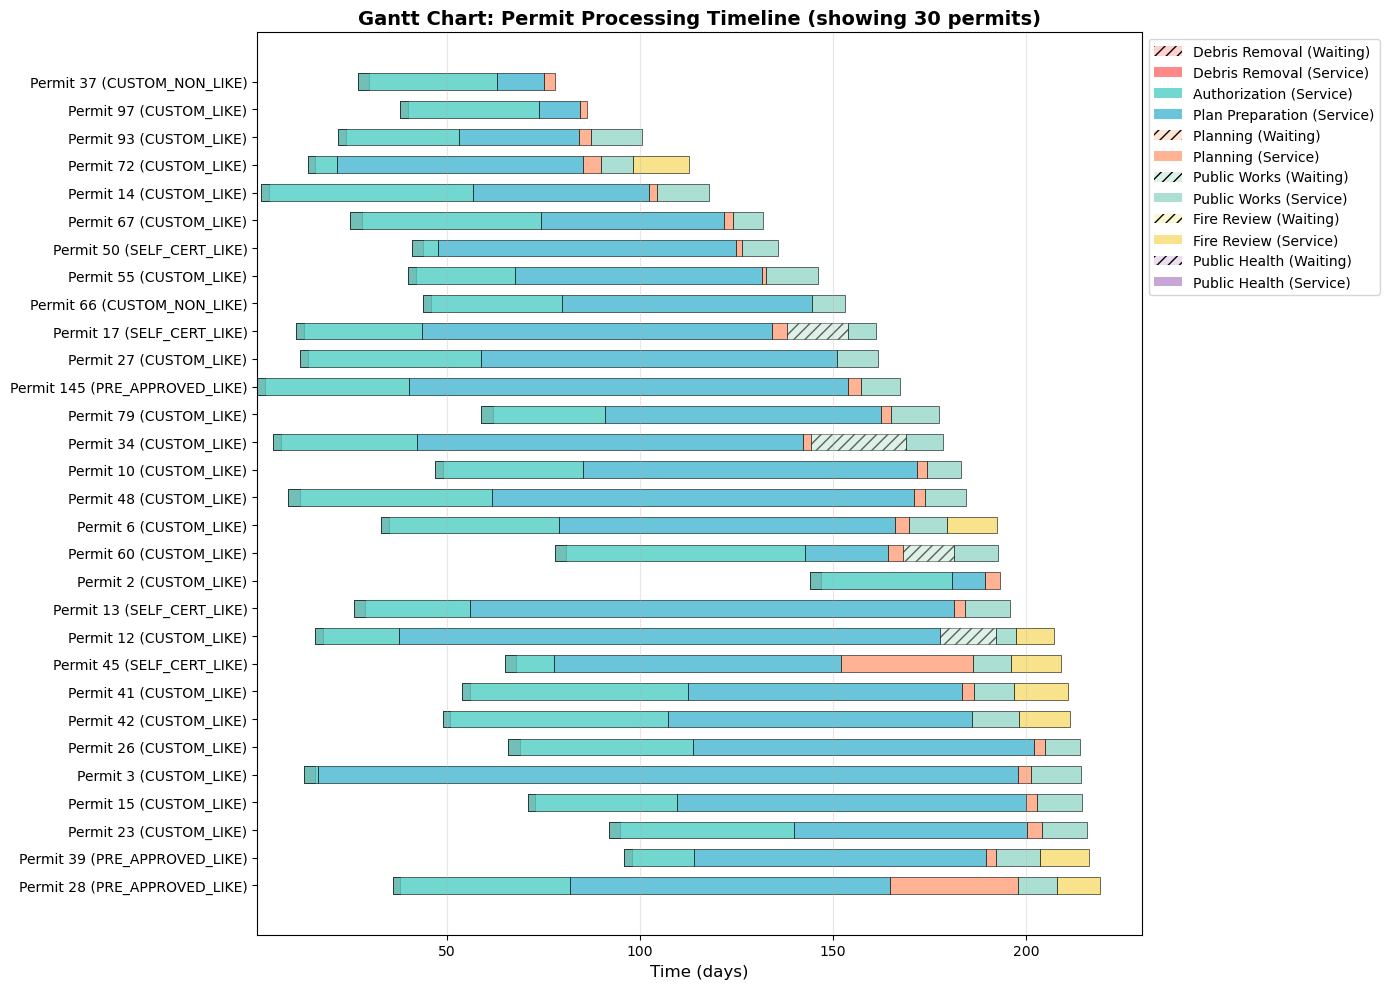

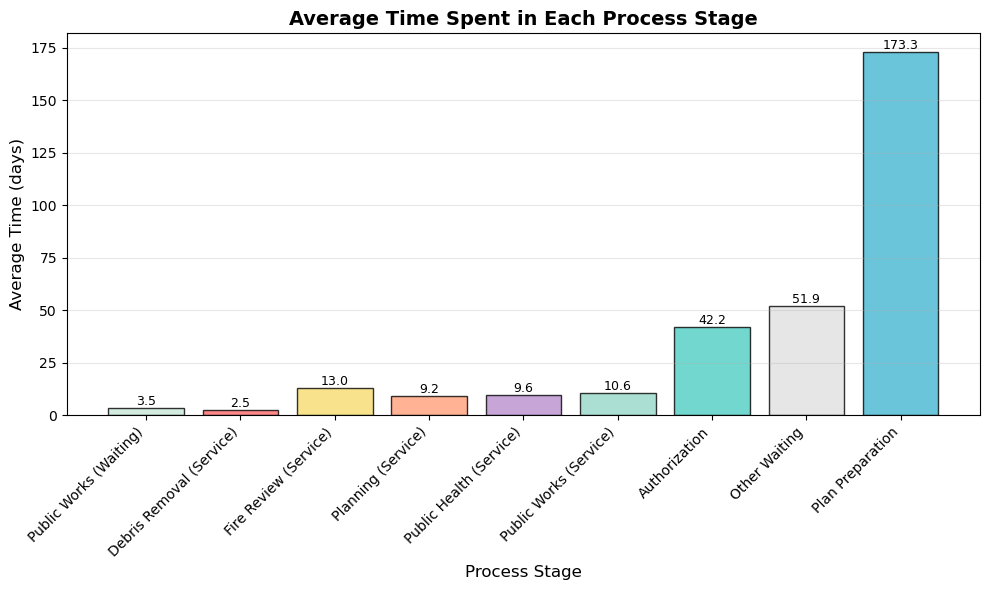

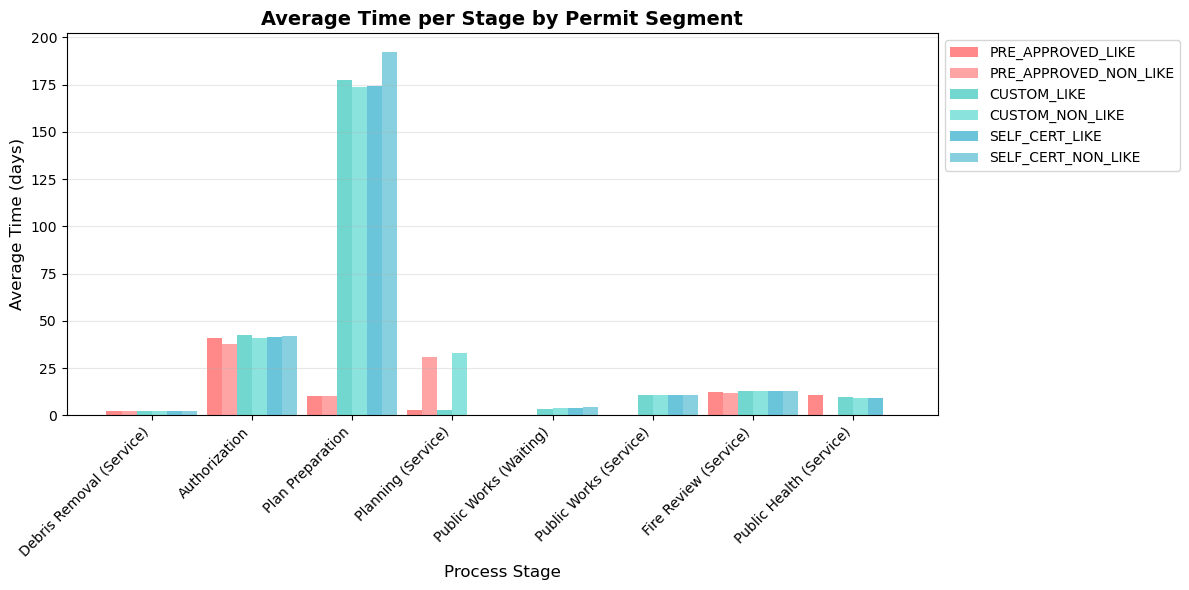

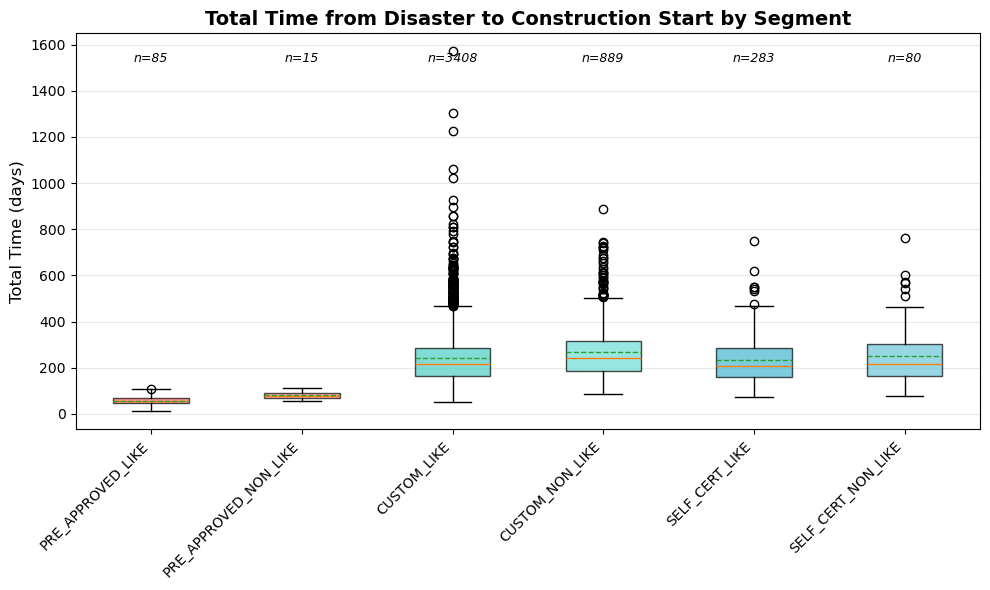

Visualizations complete!


In [ ]:
# Visualize the time each permit spends in each stage
from visualize_permits import visualize_all, plot_stacked_bar_chart, plot_gantt_chart, plot_average_time_by_stage

# Create all visualizations
visualize_all(sim.completed_permits)

# Or create individual visualizations:
# plot_stacked_bar_chart(sim.completed_permits, max_permits=30)  # Stacked bar chart
# plot_gantt_chart(sim.completed_permits, max_permits=20)        # Gantt chart
# plot_average_time_by_stage(sim.completed_permits)              # Average time by stage
